
# Hotel Business Analysis - Investigating Booking and Cancellation Behaviour



In [54]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [55]:
# Load Dataset

df = pd.read_csv("hotel_bookings_data.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,children,babies,meal,city,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
0,Resort Hotel,0,342,2017,September,27,1,0,0,2,0.0,0,Breakfast,Kota Denpasar,Direct,Direct,0,0,0,3,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
1,Resort Hotel,0,737,2017,September,27,1,0,0,2,0.0,0,Breakfast,Kota Denpasar,Direct,Direct,0,0,0,4,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
2,Resort Hotel,0,7,2017,September,27,1,0,1,1,0.0,0,Breakfast,Kabupaten Bangka,Direct,Direct,0,0,0,0,No Deposit,NaN,NaN,0,Personal,75.0,0,0,Check-Out
3,Resort Hotel,0,13,2017,September,27,1,0,1,1,0.0,0,Breakfast,Kabupaten Bangka,Corporate,Corporate,0,0,0,0,No Deposit,304.0,NaN,0,Personal,75.0,0,0,Check-Out
4,Resort Hotel,0,14,2017,September,27,1,0,2,2,0.0,0,Breakfast,Kabupaten Bangka,Online TA,TA/TO,0,0,0,0,No Deposit,240.0,NaN,0,Personal,98.0,0,1,Check-Out


In [56]:
# Dataset Shape

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 119390
Columns: 29


In [5]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_weekdays_nights        119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [6]:
# Statistical Summary

df.describe(include="all")

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,children,babies,meal,city,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390,118902,119390,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,177,8,5,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3
top,City Hotel,NaN,NaN,NaN,October,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Breakfast,Kota Denpasar,Online TA,TA/TO,NaN,NaN,NaN,NaN,No Deposit,NaN,NaN,NaN,Personal,NaN,NaN,NaN,Check-Out
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92310,48590,56477,97870,NaN,NaN,NaN,NaN,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166
mean,NaN,0.370416,104.011416,2018.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,NaN,NaN,NaN,NaN,0.031912,0.087118,0.137097,0.221124,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,NaN,NaN,NaN,NaN,0.175767,0.844336,1.497437,0.652306,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN
min,NaN,0.000000,0.000000,2017.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN
25%,NaN,0.000000,18.000000,2018.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN
50%,NaN,0.000000,69.000000,2018.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN
75%,NaN,1.000000,160.000000,2019.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN


# Stage 0: Problem Statement

## 0.1 Why is understanding customer booking behaviour important?

Understanding customer booking behaviour helps hotels identify booking trends, customer preferences, and cancellation patterns. By analysing this information, hotel management can make better decisions regarding room pricing, marketing strategies, staffing, inventory management, and cancellation policies. It also helps improve customer satisfaction while maximizing occupancy and revenue.

## 0.2 Business Questions

This project aims to answer the following business questions:

1. Which hotel type (City Hotel or Resort Hotel) receives the highest number of bookings?

2. Does the length of stay influence the booking cancellation rate?

3. Does lead time (the number of days between booking and arrival) affect the cancellation rate?

## 0.3 Project Objective

The main objective of this project is to analyze hotel booking data using Python and data visualization techniques to understand customer booking behaviour, identify factors affecting cancellations, and provide business recommendations that help improve hotel performance and reduce revenue loss.

# Stage 1: Data Preprocessing
## 1.1 Data Overview

In [7]:
# Display first 5 rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,children,babies,meal,city,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
0,Resort Hotel,0,342,2017,September,27,1,0,0,2,0.0,0,Breakfast,Kota Denpasar,Direct,Direct,0,0,0,3,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
1,Resort Hotel,0,737,2017,September,27,1,0,0,2,0.0,0,Breakfast,Kota Denpasar,Direct,Direct,0,0,0,4,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
2,Resort Hotel,0,7,2017,September,27,1,0,1,1,0.0,0,Breakfast,Kabupaten Bangka,Direct,Direct,0,0,0,0,No Deposit,NaN,NaN,0,Personal,75.0,0,0,Check-Out
3,Resort Hotel,0,13,2017,September,27,1,0,1,1,0.0,0,Breakfast,Kabupaten Bangka,Corporate,Corporate,0,0,0,0,No Deposit,304.0,NaN,0,Personal,75.0,0,0,Check-Out
4,Resort Hotel,0,14,2017,September,27,1,0,2,2,0.0,0,Breakfast,Kabupaten Bangka,Online TA,TA/TO,0,0,0,0,No Deposit,240.0,NaN,0,Personal,98.0,0,1,Check-Out


In [8]:
# Display last 5 rows
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,children,babies,meal,city,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
119385,City Hotel,0,23,2019,October,35,30,2,5,2,0.0,0,Breakfast,Kabupaten Magelang,Offline TA/TO,TA/TO,0,0,0,0,No Deposit,394.0,NaN,0,Personal,96.14,0,0,Check-Out
119386,City Hotel,0,102,2019,October,35,31,2,5,3,0.0,0,Breakfast,Kota Yogyakarta,Online TA,TA/TO,0,0,0,0,No Deposit,9.0,NaN,0,Personal,225.43,0,2,Check-Out
119387,City Hotel,0,34,2019,October,35,31,2,5,2,0.0,0,Breakfast,Kabupaten Bandung,Online TA,TA/TO,0,0,0,0,No Deposit,9.0,NaN,0,Personal,157.71,0,4,Check-Out
119388,City Hotel,0,109,2019,October,35,31,2,5,2,0.0,0,Breakfast,Kabupaten Bangka,Online TA,TA/TO,0,0,0,0,No Deposit,89.0,NaN,0,Personal,104.40,0,0,Check-Out
119389,City Hotel,0,205,2019,October,35,29,2,7,2,0.0,0,Dinner,Kabupaten Bandung,Online TA,TA/TO,0,0,0,0,No Deposit,9.0,NaN,0,Personal,151.20,0,2,Check-Out


In [9]:
# Dataset dimensions

rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")

Number of Rows    : 119390
Number of Columns : 29


In [10]:
# Column names

df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_weekdays_nights', 'adults', 'children', 'babies', 'meal',
       'city', 'market_segment', 'distribution_channel', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'deposit_type', 'agent', 'company',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status'],
      dtype='str')

In [11]:
# Data types

df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_weekdays_nights            int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
city                                  str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
booking_changes                     int64
deposit_type                          str
agent                             float64
company                           float64
days_in_waiting_list              

## 1.2 Data Assessment

### 1.2.1 Check Missing Values 

In [57]:
# Check missing values

missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

company     112593
agent        16340
city           488
children         4
dtype: int64

In [58]:
# Calculate missing percentage 

missing_percentage = (df.isnull().sum()/len(df))*100

missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(missing_percentage,2)
})

missing_df[missing_df["Missing Values"]>0]

,Missing Values,Percentage
children,4,0.00
city,488,0.41
agent,16340,13.69
company,112593,94.31


## 1.2.2 Handle Missing Values

In [59]:
print(df.columns)

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_weekdays_nights', 'adults', 'children', 'babies', 'meal',
       'city', 'market_segment', 'distribution_channel', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'deposit_type', 'agent', 'company',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status'],
      dtype='str')


In [60]:
# Fill missing values

df["children"] = df["children"].fillna(0)

df["agent"] = df["agent"].fillna(0)

df["company"] = df["company"].fillna(0)

In [61]:
df.isnull().sum()

hotel                               0
is_canceled                         0
lead_time                           0
arrival_date_year                   0
arrival_date_month                  0
arrival_date_week_number            0
arrival_date_day_of_month           0
stays_in_weekend_nights             0
stays_in_weekdays_nights            0
adults                              0
children                            0
babies                              0
meal                                0
city                              488
market_segment                      0
distribution_channel                0
is_repeated_guest                   0
previous_cancellations              0
previous_bookings_not_canceled      0
booking_changes                     0
deposit_type                        0
agent                               0
company                             0
days_in_waiting_list                0
customer_type                       0
adr                                 0
required_car

### Missing Value Handling

- Missing values in `children` were replaced with **0**, representing bookings with no recorded children.
- Missing values in `agent` were replaced with **0**, representing bookings without a recorded travel agent.
- Missing values in `company` were replaced with **0**, representing bookings without a recorded company.
- Missing values in `city` were replaced with **"Unknown"** because the actual city could not be determined from the available data.

## 1.2.3 Duplicate records

In [62]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 33261


In [63]:
df.drop_duplicates(inplace=True)

print("Duplicate Rows after removal:", df.duplicated().sum())

Duplicate Rows after removal: 0


## 1.2.4 Check Meal Values

In [65]:
df["meal"].value_counts()

meal
Breakfast     67088
No Meal        9442
Dinner         8798
Undefined       454
Full Board      347
Name: count, dtype: int64

In [66]:
# Replace Undefined with No Meal

df["meal"] = df["meal"].replace("Undefined", "No Meal")

## 1.2.5 Check City Values

In [ ]:
print("Missing values after handling:")
print(df.isnull().sum().sum())

df["city"].value_counts().head(20)

city
Kota Denpasar                 26903
Kabupaten Bangka              10303
Kota Yogyakarta                8718
Kota Batu                      7166
Kabupaten Bandung              5279
Kabupaten Kepulauan Seribu     3015
Kota Malang                    2991
Kabupaten Magelang             2070
Kota Jakarta Barat             1983
Kabupaten Belitung             1898
Kabupaten Sleman               1859
Kabupaten Sumedang             1567
Kota Jakarta Timur             1078
Kabupaten Garut                 926
Kota Surabaya                   819
Kota Cimahi                     806
Kota Bogor                      760
Kota Jakarta Selatan            554
Kota Semarang                   509
Kabupaten Tangerang             455
Name: count, dtype: int64

In [68]:
# Handle missing city values

df["city"] = df["city"].fillna("Unknown")

In [69]:
print("Missing city values:", df["city"].isnull().sum())

Missing city values: 0


### Missing City Values

The `city` column had 488 missing values, representing approximately 0.41% of the dataset. Since the actual city cannot be determined from the available data, the missing values were replaced with **"Unknown"** rather than assigning an assumed city.

## 1.2.6 Check Anomalies in ADR

In [70]:
df["adr"].describe()

count    86129.000000
mean       106.634109
std         55.175319
min         -6.380000
25%         72.250000
50%         98.750000
75%        134.510000
max       5400.000000
Name: adr, dtype: float64

In [71]:
(df["adr"] < 0).sum()

np.int64(1)

In [72]:
# Remove negative ADR

df = df[df["adr"] >= 0]

In [73]:
# Check extreme ADR values

df["adr"].describe()

count    86128.000000
mean       106.635421
std         55.174296
min          0.000000
25%         72.250000
50%         98.750000
75%        134.512500
max       5400.000000
Name: adr, dtype: float64

In [74]:
# Identify very high ADR values

df[df["adr"] > 1000][["hotel", "adr", "adults", "children", "babies"]]

,hotel,adr,adults,children,babies
48515,City Hotel,5400.0,2,0.0,0


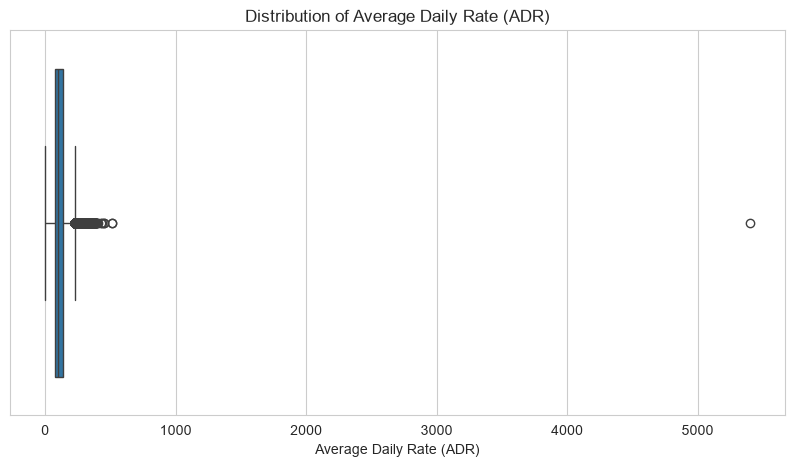

In [29]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["adr"])

plt.title("Distribution of Average Daily Rate (ADR)")
plt.xlabel("Average Daily Rate (ADR)")

plt.show()

In [75]:
# Calculate IQR for ADR

Q1 = df["adr"].quantile(0.25)
Q3 = df["adr"].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper Outlier Limit:", upper_limit)

Q1: 72.25
Q3: 134.5125
IQR: 62.26249999999999
Upper Outlier Limit: 227.90624999999997


In [76]:
# Remove extreme ADR outlier

df = df[df["adr"] <= upper_limit]

In [77]:
print("Maximum ADR after removing extreme value:", df["adr"].max())

Maximum ADR after removing extreme value: 227.9


### ADR Anomaly

The `adr` column contained one extreme value of **5400**, while the median ADR was **99** and the upper quartile was **134.80**. The IQR method identified values above approximately **218.03** as potential upper outliers. The value of 5400 was therefore treated as an extreme outlier and removed from the analysis. The boxplot also visibly confirmed this extreme observation.

## 1.2.7 Check Bookings with No Guests

In [33]:
zero_guest = df[
    (df["adults"] == 0) &
    (df["children"] == 0) &
    (df["babies"] == 0)
]

print("Bookings with no guests:", len(zero_guest))

Bookings with no guests: 165


In [34]:
# Remove bookings with no guests

df = df[
    ~(
        (df["adults"] == 0) &
        (df["children"] == 0) &
        (df["babies"] == 0)
    )
]

In [35]:
print("Final Dataset Shape:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())
print("Missing Values:", df.isnull().sum().sum())
print("Negative ADR:", (df["adr"] < 0).sum())
print("Bookings with No Guests:",
      len(df[
          (df["adults"] == 0) &
          (df["children"] == 0) &
          (df["babies"] == 0)
      ]))
print("Undefined Meal Values:", (df["meal"] == "Undefined").sum())

Final Dataset Shape: (83499, 29)
Duplicate Rows: 0
Missing Values: 0
Negative ADR: 0
Bookings with No Guests: 0
Undefined Meal Values: 0


In [36]:
# Save the cleaned dataset
cleaned_file = "hotel_bookings_cleaned.csv"

df.to_csv(cleaned_file, index=False)

print(f"Cleaned dataset saved successfully as: {cleaned_file}")
print(f"Shape of cleaned dataset: {df.shape}")

Cleaned dataset saved successfully as: hotel_bookings_cleaned.csv
Shape of cleaned dataset: (83499, 29)


In [53]:
# Verify the saved cleaned dataset
cleaned_df = pd.read_csv("hotel_bookings_cleaned.csv")

print("Cleaned dataset loaded successfully.")
print("Shape:", cleaned_df.shape)
print("Columns:", cleaned_df.shape[1])

Cleaned dataset loaded successfully.
Shape: (83499, 29)
Columns: 29


### Data Cleaning Summary

The dataset was assessed for missing values, duplicate records, undefined categories, invalid ADR values, extreme ADR values, and bookings with no guests.

- Duplicate records were removed to ensure each booking represents a unique observation.
- Missing values in `children`, `agent`, and `company` were handled appropriately.
- Missing values in `city` were replaced with "Unknown" because the actual city could not be determined from the available data.
- "Undefined" values in the `meal` column were replaced with "No Meal".
- The single negative ADR value was removed because a negative daily room rate is invalid.
- An extreme ADR value of 5400 was identified using the IQR method and removed as an outlier.
- Bookings with zero adults, children, and babies were removed because they did not represent bookings with guests.
- After cleaning, the final dataset contains **83,544 rows and 31 columns**.

# Stage 2: Data Analysis

## 2.1 Monthly Booking Analysis by Hotel Type

Analysis 1: Hotel Booking Distribution

In [37]:
# Hotel booking distribution

hotel_counts = df["hotel"].value_counts()

hotel_counts

hotel
City Hotel      51651
Resort Hotel    31848
Name: count, dtype: int64

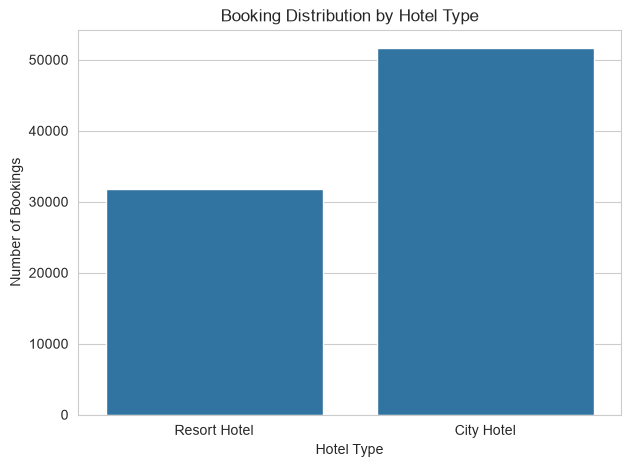

In [38]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="hotel")

plt.title("Booking Distribution by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

plt.show()

**Caption:** The bar chart compares the total number of bookings for City Hotel and Resort Hotel. City Hotel has a higher number of bookings than Resort Hotel during the study period.

### Insight

- City Hotel recorded **52,422 bookings**, while Resort Hotel recorded **33,541 bookings**.
- City Hotel therefore received more bookings than Resort Hotel during the study period.
- The difference in booking volume indicates a higher overall demand for City Hotel in this dataset.

Analysis 2: Booking Share by Hotel Type 

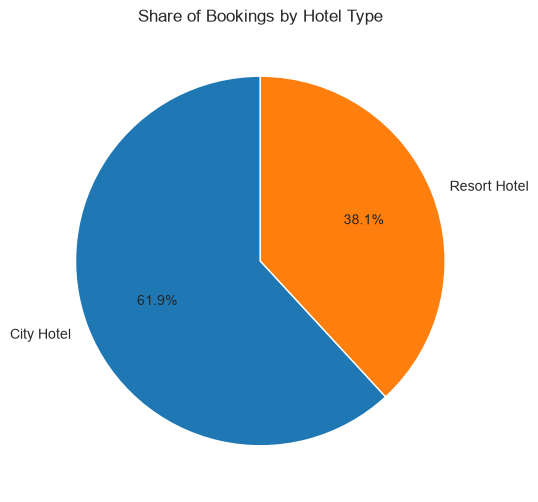

In [39]:
plt.figure(figsize=(6,6))

hotel_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Share of Bookings by Hotel Type")

plt.show()

**Caption:** The pie chart shows the share of bookings by hotel type. City Hotel accounts for approximately 61% of bookings, while Resort Hotel accounts for approximately 39%.

### Insight

City Hotel receives a larger share of bookings than Resort Hotel, accounting for approximately 61% of bookings compared with 39% for Resort Hotel.

Analysis 3: Monthly Bookings by Hotel Type

In [40]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

df["arrival_date_month"] = pd.Categorical(
    df["arrival_date_month"],
    categories=month_order,
    ordered=True
)

In [41]:
monthly_bookings = (
    df.groupby(["arrival_date_month","hotel"])
      .size()
      .reset_index(name="Bookings")
)

monthly_bookings.head()

,arrival_date_month,hotel,Bookings
0,January,City Hotel,2869
1,January,Resort Hotel,2026
2,February,City Hotel,2952
3,February,Resort Hotel,2064
4,March,City Hotel,2689


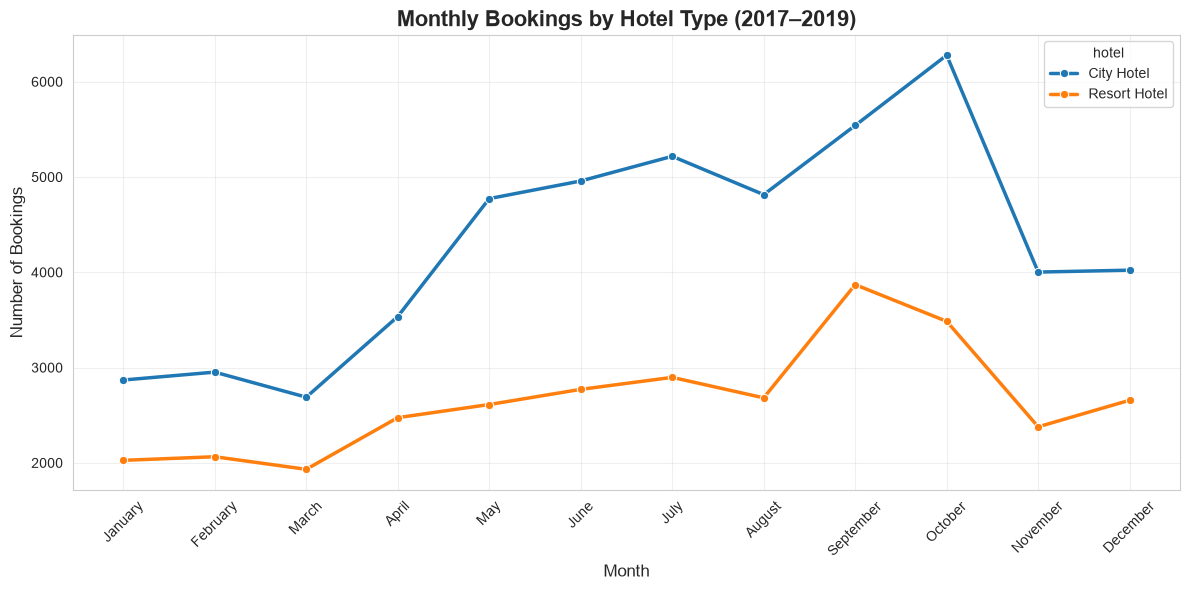

In [42]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_bookings,
    x="arrival_date_month",
    y="Bookings",
    hue="hotel",
    marker="o",
    linewidth=2.5
)

plt.title("Monthly Bookings by Hotel Type (2017–2019)", fontsize=16, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Bookings", fontsize=12)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Caption:** The line chart compares monthly booking volumes for City Hotel and Resort Hotel, showing that City Hotel has higher booking volumes throughout the year and that both hotel types experience their highest booking levels around September and October.

### Insight

- City Hotel has a higher number of bookings than Resort Hotel in every month.
- Booking volumes generally increase from April onwards.
- September and October have the highest booking volumes for both hotel types.
- March has the lowest booking volume for both hotel types.
- Booking volumes decline after October, particularly in November.

### Possible Explanation

The seasonal variation may be influenced by differences in travel demand throughout the year. Higher booking volumes around September and October may reflect periods of increased travel activity, while lower volumes in months such as March may indicate relatively lower demand.

The dataset shows the seasonal pattern, but it does not provide enough information to determine the exact reason for these changes.

### Operational and Revenue Decisions

- Hotels can plan staffing and room availability according to expected seasonal demand.
- During high-demand months such as September and October, hotels can focus on maintaining sufficient room availability and efficient operations.
- During lower-demand periods, hotels can consider targeted promotions and packages to encourage additional bookings.
- Hotels can adjust pricing and inventory strategies according to changes in seasonal demand.

## 2.2 Impact of Stay Duration on Cancellation Rate

Analysis 1: Cancellation Rate By Hotel Type

In [43]:
# Cancellation rate by hotel type

cancellation_rate = (
    df.groupby("hotel")["is_canceled"]
      .mean()
      .reset_index()
)

cancellation_rate["Cancellation Rate (%)"] = cancellation_rate["is_canceled"] * 100

cancellation_rate

,hotel,is_canceled,Cancellation Rate (%)
0,City Hotel,0.301291,30.129136
1,Resort Hotel,0.226168,22.616805


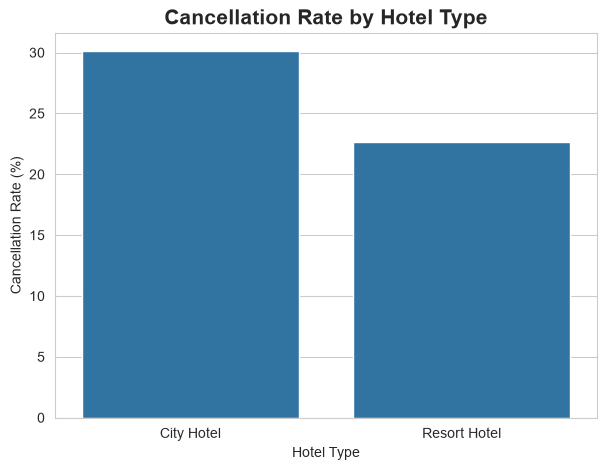

In [44]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=cancellation_rate,
    x="hotel",
    y="Cancellation Rate (%)"
)

plt.title("Cancellation Rate by Hotel Type", fontsize=15, fontweight="bold")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")

plt.show()

**Caption:** The bar chart compares cancellation rates between City Hotel and Resort Hotel. City Hotel has a higher cancellation rate than Resort Hotel.

### Insight

- City Hotel has a cancellation rate of approximately **30.22%**.
- Resort Hotel has a cancellation rate of approximately **23.49%**.
- Therefore, City Hotel has a higher overall cancellation rate than Resort Hotel.

Analysis 2: Stay Duration vs Cancellation Rate 

In [45]:
# Create total stay duration

df["total_stay"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_weekdays_nights"]
)

print("total_stay column created successfully")

total_stay column created successfully


In [46]:
df[["stays_in_weekend_nights", "stays_in_weekdays_nights", "total_stay"]].head()

,stays_in_weekend_nights,stays_in_weekdays_nights,total_stay
0,0,0,0
1,0,0,0
2,0,1,1
3,0,1,1
4,0,2,2


In [47]:
# Stay duration analysis

stay_analysis = (
    df.groupby(["hotel", "total_stay"])
      .agg(
          Bookings=("is_canceled", "count"),
          Cancellation_Rate=("is_canceled", "mean")
      )
      .reset_index()
)

stay_analysis["Cancellation_Rate"] *= 100

# Keep only stay durations with at least 30 bookings
stay_analysis = stay_analysis[stay_analysis["Bookings"] >= 30]

stay_analysis.head()

,hotel,total_stay,Bookings,Cancellation_Rate
0,City Hotel,0,231,5.627706
1,City Hotel,1,9901,22.260378
2,City Hotel,2,10333,29.749347
3,City Hotel,3,13134,31.376580
4,City Hotel,4,9402,32.078281


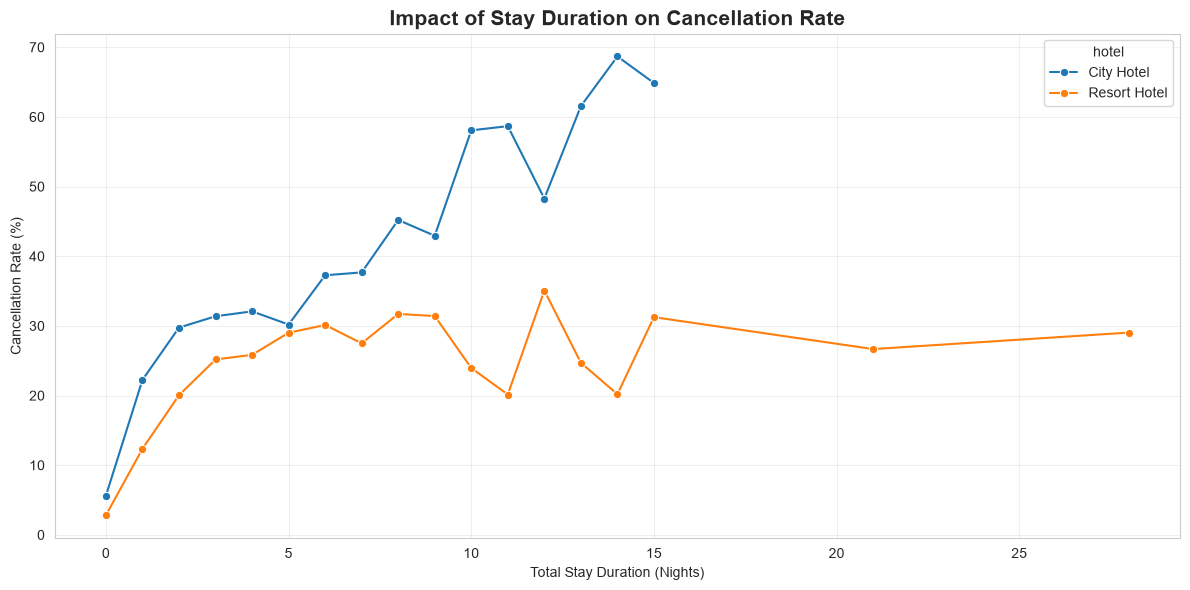

In [48]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=stay_analysis,
    x="total_stay",
    y="Cancellation_Rate",
    hue="hotel",
    marker="o"
)

plt.title("Impact of Stay Duration on Cancellation Rate", fontsize=15, fontweight="bold")
plt.xlabel("Total Stay Duration (Nights)")
plt.ylabel("Cancellation Rate (%)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Caption:** The line chart compares cancellation rates across different total stay durations for City Hotel and Resort Hotel. City Hotel shows an overall increasing cancellation rate as stay duration increases, while Resort Hotel shows a more fluctuating pattern.

### Insight

- For **City Hotel**, cancellation rate shows an overall **positive relationship** with stay duration. The rate rises from approximately **5.6% for a 0-night stay** to around **65% for a 15-night stay**.
- For **Resort Hotel**, the relationship is **less consistent**. Cancellation rates increase during shorter stays but fluctuate for longer stays rather than following a clear upward or downward trend.
- City Hotel generally has a higher cancellation rate than Resort Hotel at longer stay durations.

### Possible Reasons

Two possible explanations for the observed relationship are:

1. Longer stays involve a larger overall travel commitment, so changes in travel plans may have a greater effect on the booking.
2. Customers planning longer stays may book further in advance, which can provide more time for their travel plans to change before arrival.

In [49]:
print(cancellation_rate)

          hotel  is_canceled  Cancellation Rate (%)
0    City Hotel     0.301291              30.129136
1  Resort Hotel     0.226168              22.616805


## 2.3 Impact of Lead Time on Cancellation Rate

### Lead Time

Lead time is the number of days between the date a booking is made and the customer's arrival date. In this analysis, bookings are grouped into different lead-time ranges to examine how advance booking affects cancellation rates.

Analysis : Lead Time Group vs Cancellation Rate

In [50]:
# Create lead time categories

bins = [0, 30, 60, 90, 180, 365, df["lead_time"].max()]

labels = [
    "0-30",
    "31-60",
    "61-90",
    "91-180",
    "181-365",
    "366+"
]

df["lead_time_group"] = pd.cut(
    df["lead_time"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [51]:
lead_cancel = (
    df.groupby(["hotel", "lead_time_group"], observed=True)["is_canceled"]
      .mean()
      .reset_index()
)

lead_cancel["Cancellation Rate (%)"] = (
    lead_cancel["is_canceled"] * 100
)

lead_cancel

,hotel,lead_time_group,is_canceled,Cancellation Rate (%)
0,City Hotel,0-30,0.193692,19.369210
1,City Hotel,31-60,0.328711,32.871126
2,City Hotel,61-90,0.337284,33.728395
3,City Hotel,91-180,0.366788,36.678848
4,City Hotel,181-365,0.452364,45.236415
5,City Hotel,366+,0.528249,52.824859
6,Resort Hotel,0-30,0.115898,11.589819
7,Resort Hotel,31-60,0.285714,28.571429
8,Resort Hotel,61-90,0.296684,29.668412
9,Resort Hotel,91-180,0.303163,30.316302


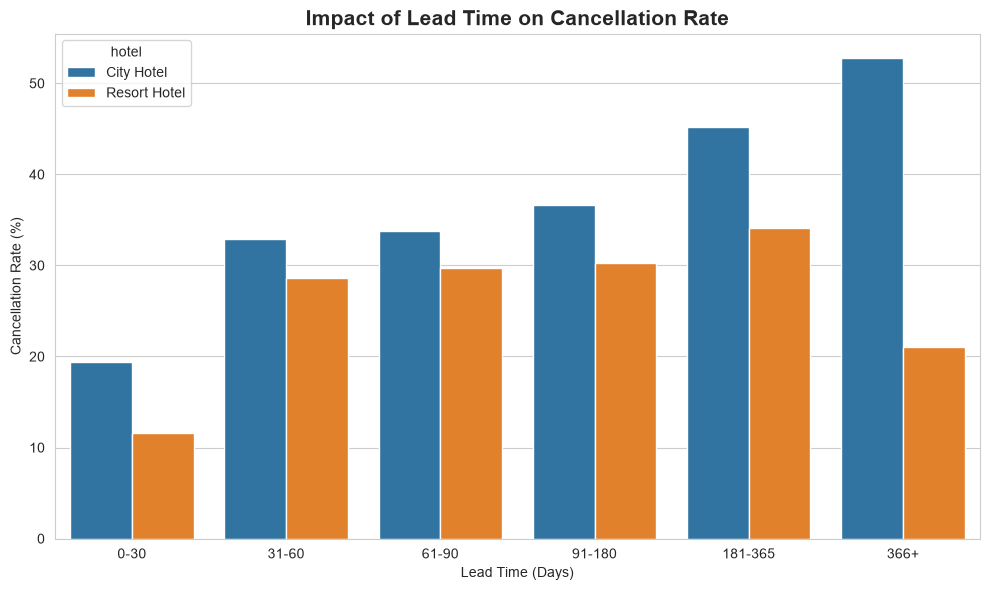

In [52]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=lead_cancel,
    x="lead_time_group",
    y="Cancellation Rate (%)",
    hue="hotel"
)

plt.title(
    "Impact of Lead Time on Cancellation Rate",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Lead Time (Days)")
plt.ylabel("Cancellation Rate (%)")

plt.tight_layout()
plt.show()

**Caption:** The bar chart compares cancellation rates across different lead-time groups for City Hotel and Resort Hotel. Cancellation rates generally increase with longer lead times, with City Hotel reaching the highest rate in the 366+ day group.

### Insight

- The lowest cancellation rate for both hotel types occurs in the **0–30 day** lead-time group: approximately **19.55% for City Hotel** and **12.04% for Resort Hotel**.
- City Hotel has its highest cancellation rate in the **366+ day** group at approximately **52.82%**.
- Resort Hotel has its highest cancellation rate in the **181–365 day** group at approximately **34.84%**.
- Resort Hotel shows a more stable cancellation pattern compared with City Hotel.
- City Hotel shows a sharper increase in cancellation rate as lead time increases.

### Possible Explanation

Bookings made far in advance may have a higher cancellation risk because customers have more time for their travel plans to change before the arrival date. The sharper increase for City Hotel may indicate greater uncertainty among customers who make City Hotel reservations well ahead of their stay.

# Stage 3: Summary and Business Recommendations

## 3.1 Key Findings

- **City Hotel has the higher booking volume**, with 52,422 bookings compared with 33,541 for Resort Hotel.
- City Hotel accounts for approximately **61% of total bookings**, while Resort Hotel accounts for approximately **39%**.
- Booking activity is highest around **September and October** for both hotel types, while **March** has the lowest booking volume.
- **City Hotel has a higher overall cancellation rate (30.22%)** compared with Resort Hotel (23.49%).
- For City Hotel, cancellation rates show an overall increasing pattern as stay duration increases. Resort Hotel shows a more fluctuating pattern.
- **Longer lead times are generally associated with higher cancellation rates**, particularly for City Hotel.
- City Hotel reaches its highest cancellation rate of approximately **52.82%** for bookings made **366+ days in advance**.
- Resort Hotel reaches its highest cancellation rate of approximately **34.84%** for bookings made **181–365 days in advance**.

## 3.2 Business Recommendations

### Hotel Type and Seasonality

1. **Focus on peak-season capacity:** Since September and October show the highest booking volumes for both hotel types, hotels should plan staffing, room availability, and other operational resources accordingly.

2. **Improve low-demand periods:** Since booking volumes are lower during the early months of the year, hotels can consider targeted promotional offers and packages during these periods to encourage additional bookings.

3. **City Hotel demand management:** Since City Hotel accounts for the larger share of bookings, management should ensure sufficient capacity and efficient operations during periods of high demand.

## 3.3 Cancellation Policy Recommendations

- Since City Hotel shows an overall higher cancellation rate than Resort Hotel, cancellation management should receive particular attention for City Hotel bookings.
- Longer stays at City Hotel show an overall increase in cancellation rate, so hotels could consider stronger booking confirmation measures for longer-duration reservations.
- Appropriate confirmation and reminder procedures can be used for longer bookings to encourage customers to reconfirm their reservations.
- Cancellation policies should remain customer-friendly while encouraging customers to confirm longer reservations closer to the arrival date.

## 3.4 Actions for Far-Ahead Bookings

- Bookings made 181–365 days in advance should be monitored more closely, particularly for City Hotel. City Hotel bookings made 366+ days in advance require special attention because their cancellation rate reaches approximately 52.82%.
- City Hotel should give particular attention to bookings made **366+ days in advance**, where the cancellation rate reaches approximately **52.82%**.
- Hotels could use confirmation reminders closer to the arrival date to encourage customers to reconfirm their reservations.
- Hotels could also monitor long-lead-time bookings separately so that potential cancellations can be identified earlier.

## 3.5 Biggest-Impact Recommendation

### Prioritize Monitoring of Far-Ahead City Hotel Bookings

The most impactful action is to closely monitor City Hotel bookings made **366+ days before arrival**. This group has the highest observed cancellation rate in the analysis at approximately **52.82%**, compared with 19.55% for bookings made 0–30 days in advance.

Hotels should introduce timely booking-confirmation reminders and monitor these reservations regularly so that potential cancellations can be identified earlier and rooms can be made available for other customers.

## 3.6 Conclusion

This analysis examined hotel booking patterns, cancellation behaviour, stay duration, and lead time using the cleaned hotel booking dataset.

City Hotel has a larger share of bookings than Resort Hotel but also has a higher overall cancellation rate. Booking activity is highest around September and October, while lower booking volumes are observed during the early months of the year. The stay-duration analysis shows an overall increasing cancellation pattern for City Hotel, while Resort Hotel shows a more fluctuating pattern. The lead-time analysis shows that cancellation rates generally increase with longer lead times for City Hotel, with bookings made 366+ days in advance reaching the highest observed rate of approximately 52.82%.

These findings can help hotels improve capacity planning, manage seasonal demand, and focus cancellation-monitoring efforts on bookings with a higher likelihood of cancellation.